# M6: Ensemble Virtual Screening

Goal: combine the three trained representations (Morgan, molecular graph, SMILES Transformer) into an ensemble and rank a local candidate library of molecules that were **not** used in the M1 modeling dataset.

The heavy training/ranking is done by `src/models/virtual_screening.py` (about 12 minutes on CPU). This notebook loads the saved results for inspection and can retrain with `M6_RETRAIN=1`.


In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Candidate library and ensemble results


In [2]:
results = json.loads((RESULTS_DIR / "m6_virtual_screening_results.json").read_text())
candidates = pd.read_csv(PROJECT_ROOT / results["candidate_library"])
print(f"candidates: {len(candidates):,}")
print(f"training molecules: {results['n_training_molecules']:,}")
print(f"ensemble: {results['ensemble']['strategy']}")

candidates: 60
training molecules: 10,161
ensemble: mean of Morgan / graph / Transformer pIC50 predictions


## 2. Top 10 shortlist


In [3]:
top = pd.DataFrame(results["shortlist"]).head(10)[
    ["ensemble_rank", "molecule_chembl_id", "ensemble_pic50", "canonical_smiles"]
]
top["canonical_smiles"] = top["canonical_smiles"].str.slice(0, 50)
top

,ensemble_rank,molecule_chembl_id,ensemble_pic50,canonical_smiles
0,1,CHEMBL2316916,7.233833,COc1ccc(Cc2nc(-c3cc(Br)c(OCCCN(C)C)c(Br)c3)c[n...
1,2,CHEMBL4531006,6.252759,N=C1NC(=O)/C(=C2/CCNC(=O)c3[nH]c(Br)c(Br)c32)N1
2,3,CHEMBL5614250,6.196074,COC(=O)c1c(C(F)(F)F)nc2c(c1-c1ccc(S(=O)(=O)c3c...
3,4,CHEMBL4539558,6.082250,N=C1NC(=O)/C(=C2/CCNC(=O)c3[nH]cc(Br)c32)N1
4,5,CHEMBL13983,5.993042,Cc1[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c(C)c1C(=O)N...
5,6,CHEMBL2315696,5.963585,C=C1[C@H](C)CCC[C@]1(C)CC/C(C)=C/CC1=C(O)C(=O)...
6,7,CHEMBL2315698,5.941995,C=C1[C@H](C)CCC[C@]1(C)CC/C(C)=C/CC1=C(O)C(=O)...
7,8,CHEMBL2315409,5.914335,C=C1[C@H](C)CCC[C@]1(C)CC/C(C)=C/CC1=C(O)C(=O)...
8,9,CHEMBL484321,5.843978,CC(C)(C)OC[C@H](Cn1ccnc1[N+](=O)[O-])OC(=O)c1c...
9,10,CHEMBL5564149,5.833810,CCOC(=O)c1nn(-c2ccccc2)c(=O)c2c(N)c(C#N)c(-c3c...


## 3. Ensemble score distribution and top 20


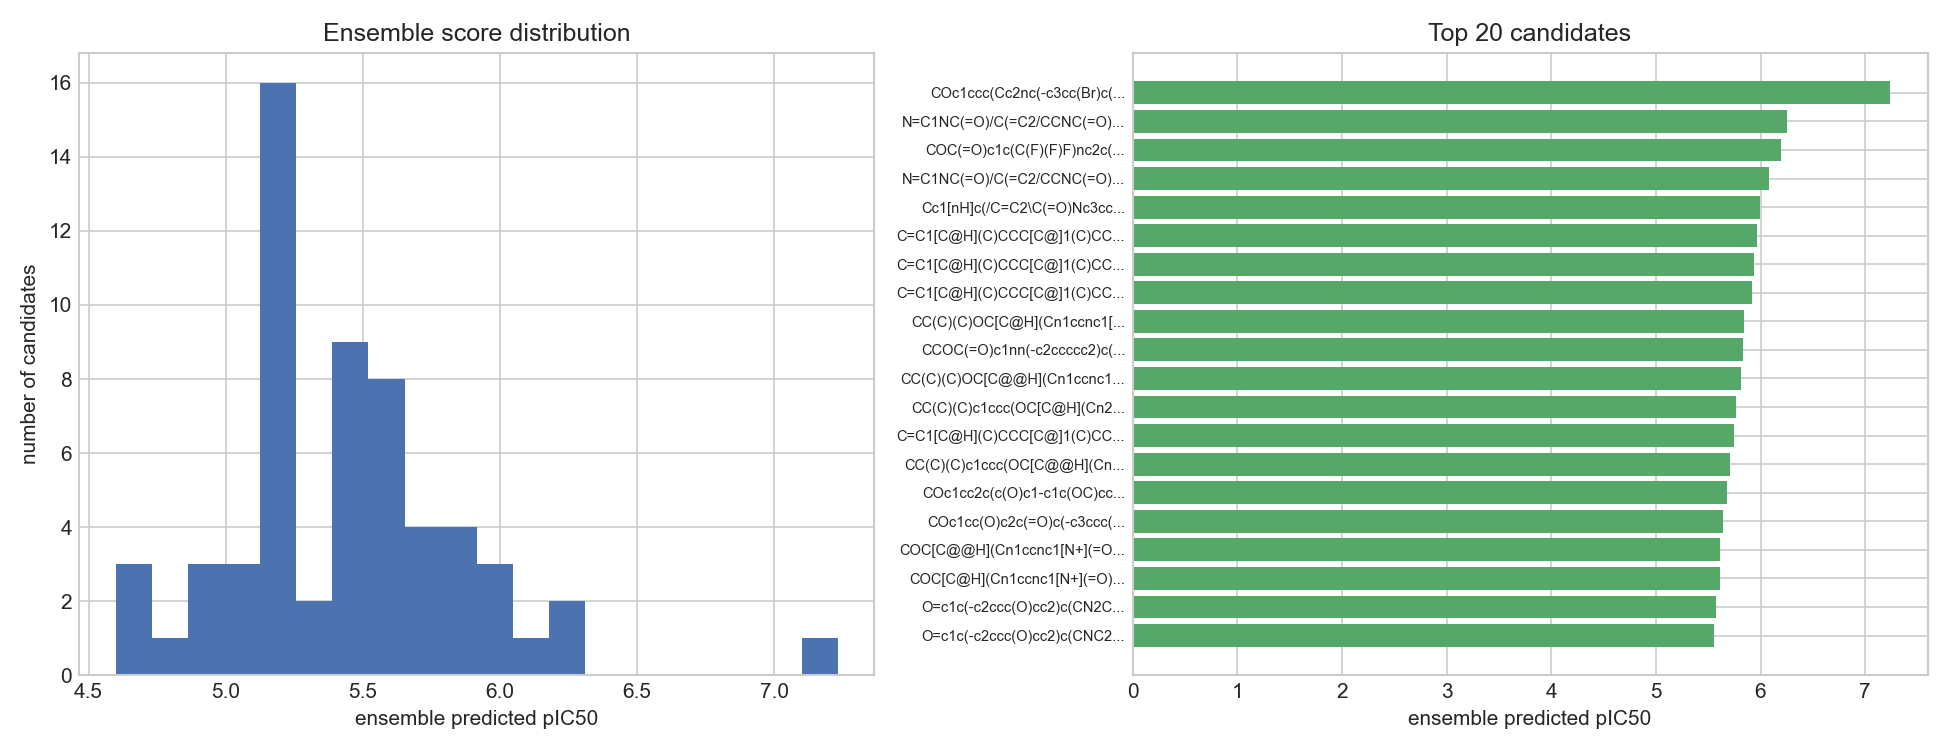

In [4]:
all_predictions = pd.DataFrame(results["candidate_predictions"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(all_predictions["ensemble_pic50"], bins=20, color="#4C72B0")
axes[0].set_xlabel("ensemble predicted pIC50")
axes[0].set_ylabel("number of candidates")
axes[0].set_title("Ensemble score distribution")

top20 = all_predictions.head(20).iloc[::-1]
labels = [s[:25] + ("..." if len(s) > 25 else "") for s in top20["canonical_smiles"]]
axes[1].barh(np.arange(len(top20)), top20["ensemble_pic50"], color="#55A868")
axes[1].set_yticks(np.arange(len(top20)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel("ensemble predicted pIC50")
axes[1].set_title("Top 20 candidates")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m6_virtual_screening_shortlist.png", dpi=150)
plt.show()

## 4. Reproduction and interpretation

- The script `src/models/virtual_screening.py` is the canonical reproduction entry; set `M6_RETRAIN=1` before running this notebook to retrain.
- Candidate library: 60 ChEMBL molecules that were not part of the M1 modeling dataset, standardized with the same RDKit pipeline.
- Ensemble: mean of Morgan (RF/XGB), graph (GCN/GIN), and SMILES Transformer predicted pIC50.
- These are computational rankings only; M7 will add ADMET and docking filters before calling anything a hit.
